# HW1 — Q-Learning 智慧溫室代理人

本 Notebook 包含 **6 組對照實驗**，透過修改不同超參數或獎勵設計，驗證 Q-Learning 在智慧溫室中的行為差異。

---

## 六組實驗差異總覽

| # | 實驗名稱 | 修改的變數 | 改動說明 | 預期觀察 |
|---|---------|-----------|---------|---------|
| 1 | **Baseline（基準模型）** | 無（預設值） | `α=0.1, γ=0.9, ε_decay=0.995, 水費=-2, 電費=-5, 蒸發率=20%` | Agent 穩定收斂至高分，作為對照基準 |
| 2 | **Reward Shaping（獎勵塑形）** | `water_cost`, `heater_cost` | 水費 -2→**-15**，電費 -5→**-30**（極端高成本） | Agent 會學到「省錢策略」，延遲開機、少用加熱器，總分上限降低 |
| 3 | **Low Gamma（短視近利）** | `discount_factor` | γ 從 0.9→**0.1** | Agent 只在乎即時獎勵，忽略長期後果，學習曲線震盪劇烈 |
| 4 | **High Evaporation（高蒸發率）** | `moisture_decay_prob` | 水分蒸發機率 20%→**80%** | 環境惡劣度大增，Agent 需大量灌溉才能存活，整體分數降低 |
| 5 | **Fast Epsilon Decay（過早收斂）** | `epsilon_decay` | ε_decay 從 0.995→**0.8**（探索率急速歸零） | Agent 過早放棄探索，鎖定局部最佳解，遇罕見狀態易崩盤 |
| 6 | **High Learning Rate（災難性遺忘）** | `learning_rate` | α 從 0.1→**1.0**（完全覆寫舊經驗） | Agent 無法累積經驗，策略隨雜訊劇烈擺盪，永遠無法收斂 |

---
## 共用程式碼：環境、Agent、訓練與測試函式

In [1]:
# ==========================================
# 0. 環境設定：中文字體 & 隱藏警告
# ==========================================
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib as mpl
import os, subprocess, sys

def setup_chinese_font():
    """自動偵測環境，設定中文字體（支援 Windows / Colab / Linux）"""
    if 'google.colab' in sys.modules or os.path.exists('/content'):
        # --- Colab 環境：安裝 Noto Sans CJK ---
        subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-noto-cjk'],
                       capture_output=True)
        mpl.font_manager.fontManager.addfont(
            '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc')
        mpl.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
    else:
        # --- Windows / 本機環境 ---
        mpl.rcParams['font.sans-serif'] = [
            'Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
    mpl.rcParams['axes.unicode_minus'] = False

setup_chinese_font()

import numpy as np
import random
import matplotlib.pyplot as plt

# ==========================================
# 1. 環境定義 (Environment)
# ==========================================
class SmartGreenhouseEnv:
    """智慧溫室環境 — 可透過參數調整獎勵與蒸發機率"""

    def __init__(self, water_cost=-2, heater_cost=-5, moisture_decay_prob=0.2):
        self.state_space = [3, 3, 3]  # 濕度, 溫度, 光照
        self.action_space = 7
        self.state = [1, 1, 1]
        # ★ 可調參數
        self.water_cost = water_cost
        self.heater_cost = heater_cost
        self.moisture_decay_prob = moisture_decay_prob

    def reset(self):
        self.state = [random.randint(0, 2) for _ in range(3)]
        return self._get_state_index()

    def step(self, action):
        self._update_state(action)
        reward = self._calculate_reward(action)
        done = False
        return self._get_state_index(), reward, done

    def _update_state(self, action):
        moisture, temp, light = self.state
        if action == 1:   moisture = min(2, moisture + 1)
        elif action == 3: temp = min(2, temp + 1)
        elif action == 5: light = min(2, light + 1)
        elif action == 6: light = max(0, light - 1)

        # ★ 隨機蒸發 (機率由 moisture_decay_prob 控制)
        if random.random() < self.moisture_decay_prob:
            moisture = max(0, moisture - 1)

        self.state = [moisture, temp, light]

    def _calculate_reward(self, action):
        reward = 0
        moisture, temp, light = self.state

        # 植物健康獎勵
        if moisture == 1: reward += 10
        elif moisture == 0: reward -= 20

        if temp == 1: reward += 10
        elif temp in (0, 2): reward -= 15

        if light == 1: reward += 5

        # ★ 資源成本 (由建構參數控制)
        if action == 1: reward += self.water_cost
        if action == 3: reward += self.heater_cost

        return reward

    def _get_state_index(self):
        m, t, l = self.state
        return m * 9 + t * 3 + l


# ==========================================
# 2. Q-Learning Agent
# ==========================================
class QLearningAgent:
    def __init__(self, state_size, action_size,
                 learning_rate=0.1, discount_factor=0.9,
                 epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.state_size = state_size
        self.action_size = action_size
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = np.zeros((state_size, action_size))

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state):
        best_next = np.argmax(self.q_table[next_state])
        td_target = reward + self.gamma * self.q_table[next_state][best_next]
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.lr * td_error

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


# ==========================================
# 3. 通用訓練函式
# ==========================================
def train(env, agent, episodes=1000, max_steps=50, label=""):
    """訓練 agent 並回傳每回合獎勵歷史"""
    rewards_history = []
    print(f"{'='*60}")
    print(f"開始訓練：{label}")
    print(f"{'='*60}")

    for e in range(episodes):
        state = env.reset()
        total_reward = 0

        for _ in range(max_steps):
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.learn(state, action, reward, next_state)
            state = next_state
            total_reward += reward

        agent.decay_epsilon()
        rewards_history.append(total_reward)

        if (e + 1) % 200 == 0:
            avg = np.mean(rewards_history[-200:])
            print(f"  Episode {e+1:>4}/{episodes} | Avg Reward: {avg:>8.2f} | \u03b5: {agent.epsilon:.4f}")

    print(f"訓練完成！最後 200 回合平均: {np.mean(rewards_history[-200:]):.2f}\n")
    return rewards_history


# ==========================================
# 4. 通用測試函式
# ==========================================
def test(env, agent, test_episodes=10, max_steps=50, label=""):
    """固定 Q-Table、關閉探索，執行獨立測試"""
    test_rewards = []
    print(f"--- 測試：{label} (\u03b5=0) ---")

    for ep in range(test_episodes):
        state = env.reset()
        ep_reward = 0
        for _ in range(max_steps):
            action = np.argmax(agent.q_table[state])
            next_state, reward, done = env.step(action)
            ep_reward += reward
            state = next_state
        test_rewards.append(ep_reward)
        print(f"  Test {ep+1:>2}/{test_episodes} \u2192 Reward: {ep_reward:>8.2f}")

    avg = np.mean(test_rewards)
    print(f"  \u2605 測試平均: {avg:.2f}\n")
    return test_rewards


# ==========================================
# 5. 通用繪圖函式
# ==========================================
def plot_train(rewards_history, title):
    """繪製訓練學習曲線"""
    plt.figure(figsize=(10, 4))
    plt.plot(rewards_history, alpha=0.4, label='每回合獎勵')
    ma = np.convolve(rewards_history, np.ones(50)/50, mode='valid')
    plt.plot(ma, color='red', linewidth=2, label='移動平均 (50 ep)')
    plt.title(title, fontsize=13)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_test(test_rewards, title):
    """繪製測試結果長條圖"""
    n = len(test_rewards)
    avg = np.mean(test_rewards)
    plt.figure(figsize=(8, 4))
    plt.bar(range(1, n+1), test_rewards, color='royalblue', alpha=0.8, edgecolor='black')
    plt.axhline(y=avg, color='red', linestyle='--', linewidth=2, label=f'Avg ({avg:.1f})')
    plt.title(title, fontsize=13)
    plt.xlabel('Test Episode')
    plt.ylabel('Total Reward')
    plt.xticks(range(1, n+1))
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

---
## 實驗 1：Baseline（基準模型）

使用所有預設超參數：`α=0.1, γ=0.9, ε_decay=0.995`，水費 `-2`，電費 `-5`，蒸發率 `20%`。

**目的**：建立效能基準線，驗證 Agent 能在約 600 episodes 後穩定收斂至高分 (~480)。

開始訓練：實驗1 — Baseline（基準模型）
  Episode  200/1000 | Avg Reward:  -519.27 | ε: 0.3670
  Episode  400/1000 | Avg Reward:   -55.64 | ε: 0.1347
  Episode  600/1000 | Avg Reward:   228.91 | ε: 0.0494
  Episode  800/1000 | Avg Reward:   406.39 | ε: 0.0181
  Episode 1000/1000 | Avg Reward:   419.48 | ε: 0.0100
訓練完成！最後 200 回合平均: 419.48



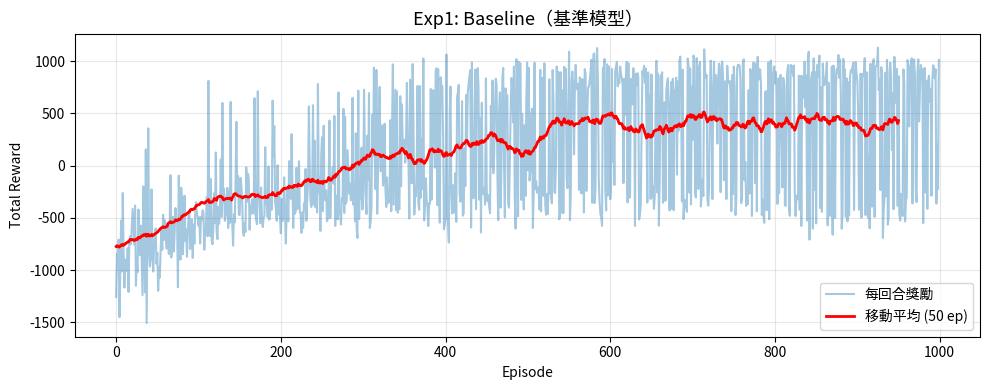

--- 測試：實驗1 (ε=0) ---
  Test  1/10 → Reward:   987.00
  Test  2/10 → Reward:  -482.00
  Test  3/10 → Reward:  1026.00
  Test  4/10 → Reward:   782.00
  Test  5/10 → Reward:  -656.00
  Test  6/10 → Reward:  -192.00
  Test  7/10 → Reward:  -694.00
  Test  8/10 → Reward:   819.00
  Test  9/10 → Reward:   866.00
  Test 10/10 → Reward:  -352.00
  ★ 測試平均: 210.40



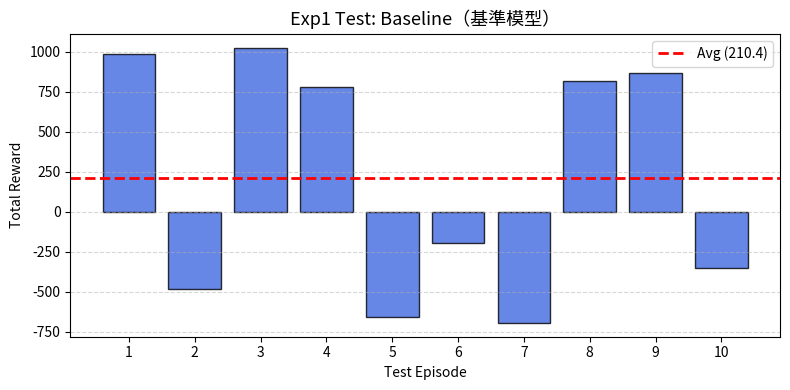

In [2]:
env = SmartGreenhouseEnv()
agent = QLearningAgent(3 * 3 * 3, 7)

# --- 訓練 ---
rewards = train(env, agent, label="實驗1 — Baseline（基準模型）")
plot_train(rewards, 'Exp1: Baseline（基準模型）')

# --- 測試 ---
test_r = test(env, agent, label="實驗1")
plot_test(test_r, 'Exp1 Test: Baseline（基準模型）')

---
## 實驗 2：Reward Shaping（獎勵塑形 — 極端高水電費）

**改動**：`water_cost=-15`（原 -2），`heater_cost=-30`（原 -5）。

**目的**：觀察獎勵權重對策略的影響。當水電成本暴增時，Agent 會學到「極限邊緣試探」策略——延遲開機時間以省錢，即使犧牲部分植物健康分數。總分上限因成本懲罰而顯著降低。

開始訓練：實驗2 — Reward Shaping（獎勵塑形 — 極端高水電費）
  Episode  200/1000 | Avg Reward:  -775.90 | ε: 0.3670
  Episode  400/1000 | Avg Reward:  -227.15 | ε: 0.1347
  Episode  600/1000 | Avg Reward:   104.45 | ε: 0.0494
  Episode  800/1000 | Avg Reward:   247.78 | ε: 0.0181
  Episode 1000/1000 | Avg Reward:   256.12 | ε: 0.0100
訓練完成！最後 200 回合平均: 256.12



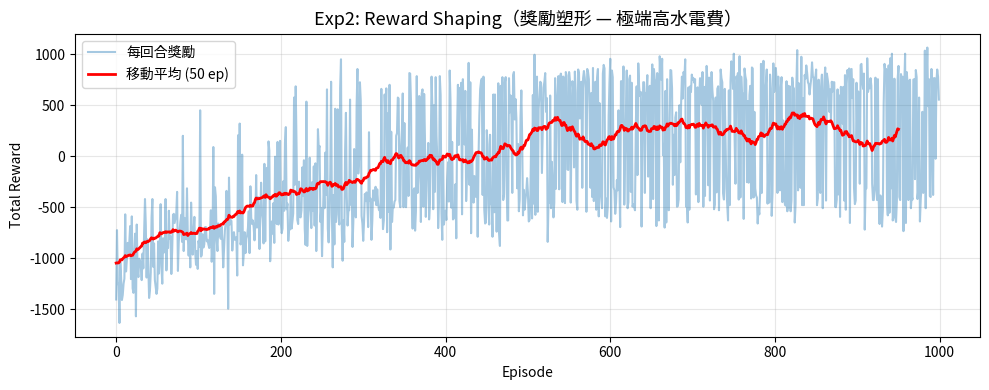

--- 測試：實驗2 (ε=0) ---
  Test  1/10 → Reward:  -420.00
  Test  2/10 → Reward:   705.00
  Test  3/10 → Reward:   575.00
  Test  4/10 → Reward:  -335.00
  Test  5/10 → Reward:  -315.00
  Test  6/10 → Reward:   750.00
  Test  7/10 → Reward:   845.00
  Test  8/10 → Reward:   895.00
  Test  9/10 → Reward:   810.00
  Test 10/10 → Reward:  -175.00
  ★ 測試平均: 333.50



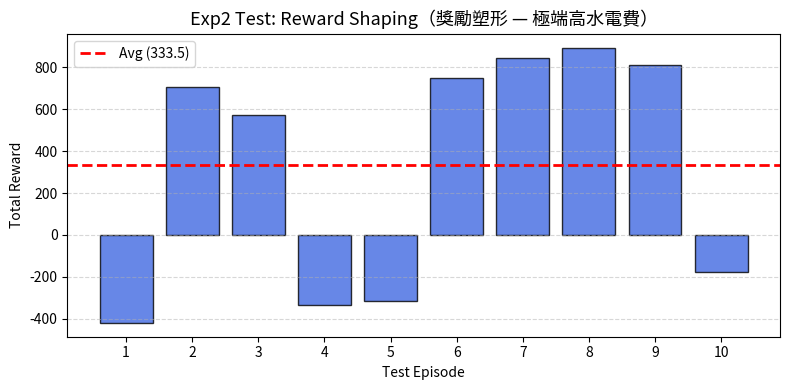

In [3]:
env = SmartGreenhouseEnv(water_cost=-15, heater_cost=-30)
agent = QLearningAgent(3 * 3 * 3, 7)

# --- 訓練 ---
rewards = train(env, agent, label="實驗2 — Reward Shaping（獎勵塑形 — 極端高水電費）")
plot_train(rewards, 'Exp2: Reward Shaping（獎勵塑形 — 極端高水電費）')

# --- 測試 ---
test_r = test(env, agent, label="實驗2")
plot_test(test_r, 'Exp2 Test: Reward Shaping（獎勵塑形 — 極端高水電費）')

---
## 實驗 3：Low Gamma（短視近利 — γ=0.1）

**改動**：`discount_factor=0.1`（原 0.9）。

**目的**：模擬短視近利的 Agent。低 γ 使 Agent 幾乎不考慮未來獎勵，只在乎當下一步的回報。結果：面對環境長期變化時極度脆弱，學習曲線震盪劇烈，最終陷入次優解。

開始訓練：實驗3 — Low Gamma（短視近利 — γ=0.1）
  Episode  200/1000 | Avg Reward:  -462.71 | ε: 0.3670
  Episode  400/1000 | Avg Reward:   -12.89 | ε: 0.1347
  Episode  600/1000 | Avg Reward:   241.28 | ε: 0.0494
  Episode  800/1000 | Avg Reward:   362.19 | ε: 0.0181
  Episode 1000/1000 | Avg Reward:   333.52 | ε: 0.0100
訓練完成！最後 200 回合平均: 333.52



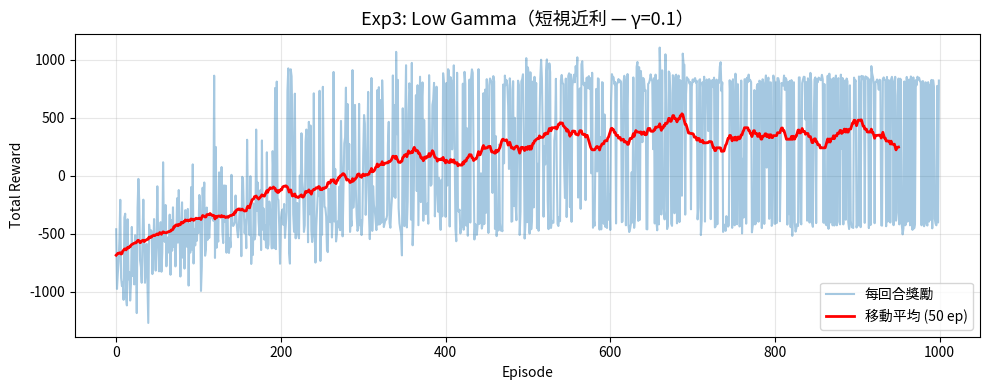

--- 測試：實驗3 (ε=0) ---
  Test  1/10 → Reward:   827.00
  Test  2/10 → Reward:   860.00
  Test  3/10 → Reward:   830.00
  Test  4/10 → Reward:   836.00
  Test  5/10 → Reward:  -407.00
  Test  6/10 → Reward:  -420.00
  Test  7/10 → Reward: -1750.00
  Test  8/10 → Reward:   830.00
  Test  9/10 → Reward:  -412.00
  Test 10/10 → Reward:   803.00
  ★ 測試平均: 199.70



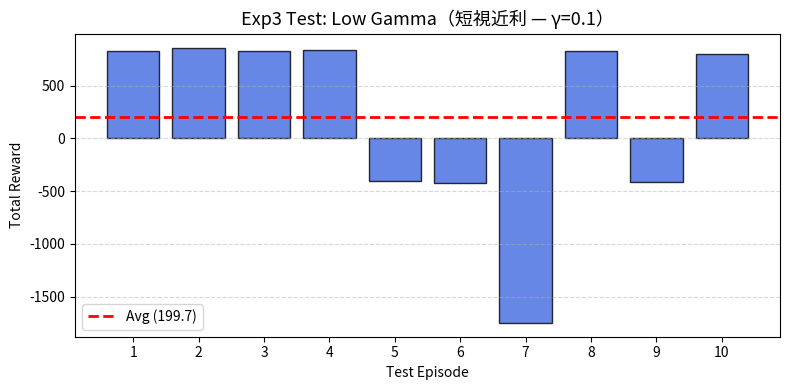

In [4]:
env = SmartGreenhouseEnv()
agent = QLearningAgent(3 * 3 * 3, 7, discount_factor=0.1)

# --- 訓練 ---
rewards = train(env, agent, label="實驗3 — Low Gamma（短視近利 — γ=0.1）")
plot_train(rewards, 'Exp3: Low Gamma（短視近利 — γ=0.1）')

# --- 測試 ---
test_r = test(env, agent, label="實驗3")
plot_test(test_r, 'Exp3 Test: Low Gamma（短視近利 — γ=0.1）')

---
## 實驗 4：High Evaporation（高蒸發率 — 80%）

**改動**：`moisture_decay_prob=0.8`（原 0.2）。

**目的**：測試環境惡劣度對 Agent 的影響。80% 的水分蒸發率使土壤迅速乾涸，Agent 必須頻繁開啟水幫浦才能維持濕度，但這也增加了水費成本。整體分數因環境壓力而降低。

開始訓練：實驗4 — High Evaporation（高蒸發率 — 80%）
  Episode  200/1000 | Avg Reward: -1219.42 | ε: 0.3670
  Episode  400/1000 | Avg Reward:  -508.57 | ε: 0.1347
  Episode  600/1000 | Avg Reward:    61.62 | ε: 0.0494
  Episode  800/1000 | Avg Reward:   371.32 | ε: 0.0181
  Episode 1000/1000 | Avg Reward:   553.64 | ε: 0.0100
訓練完成！最後 200 回合平均: 553.64



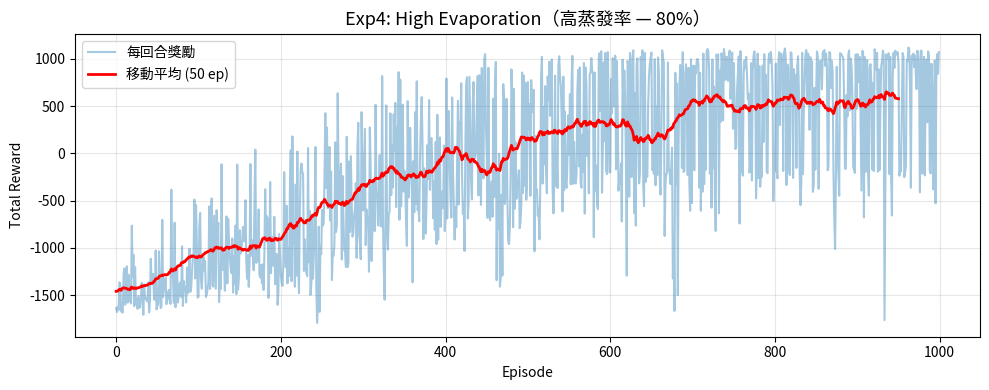

--- 測試：實驗4 (ε=0) ---
  Test  1/10 → Reward:  -422.00
  Test  2/10 → Reward:   957.00
  Test  3/10 → Reward:  1072.00
  Test  4/10 → Reward:   936.00
  Test  5/10 → Reward:  -220.00
  Test  6/10 → Reward:  -541.00
  Test  7/10 → Reward:   904.00
  Test  8/10 → Reward:  1028.00
  Test  9/10 → Reward:  1048.00
  Test 10/10 → Reward:  1030.00
  ★ 測試平均: 579.20



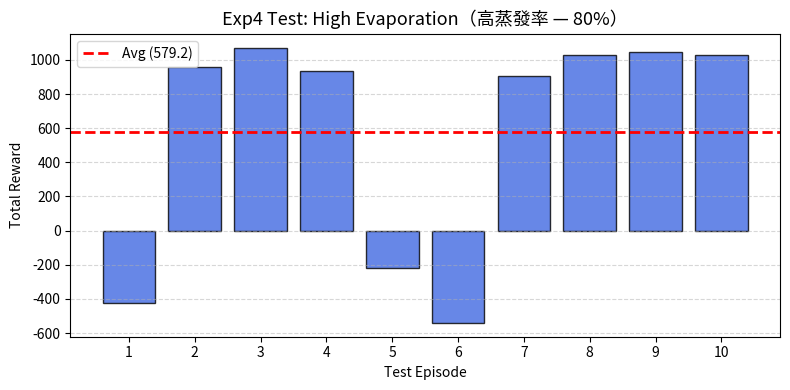

In [5]:
env = SmartGreenhouseEnv(moisture_decay_prob=0.8)
agent = QLearningAgent(3 * 3 * 3, 7)

# --- 訓練 ---
rewards = train(env, agent, label="實驗4 — High Evaporation（高蒸發率 — 80%）")
plot_train(rewards, 'Exp4: High Evaporation（高蒸發率 — 80%）')

# --- 測試 ---
test_r = test(env, agent, label="實驗4")
plot_test(test_r, 'Exp4 Test: High Evaporation（高蒸發率 — 80%）')

---
## 實驗 5：Fast Epsilon Decay（過早收斂 — ε_decay=0.8）

**改動**：`epsilon_decay=0.8`（原 0.995）。

**目的**：觀察探索不足的後果。ε 衰減過快導致 Agent 在訓練初期就幾乎停止探索，鎖死在局部最佳解中。遇到訓練時罕見的狀態組合時，Agent 表現急遽下降。

開始訓練：實驗5 — Fast Epsilon Decay（過早收斂 — ε_decay=0.8）
  Episode  200/1000 | Avg Reward:   336.36 | ε: 0.0092
  Episode  400/1000 | Avg Reward:   358.05 | ε: 0.0092
  Episode  600/1000 | Avg Reward:   462.83 | ε: 0.0092
  Episode  800/1000 | Avg Reward:   494.12 | ε: 0.0092
  Episode 1000/1000 | Avg Reward:   452.10 | ε: 0.0092
訓練完成！最後 200 回合平均: 452.10



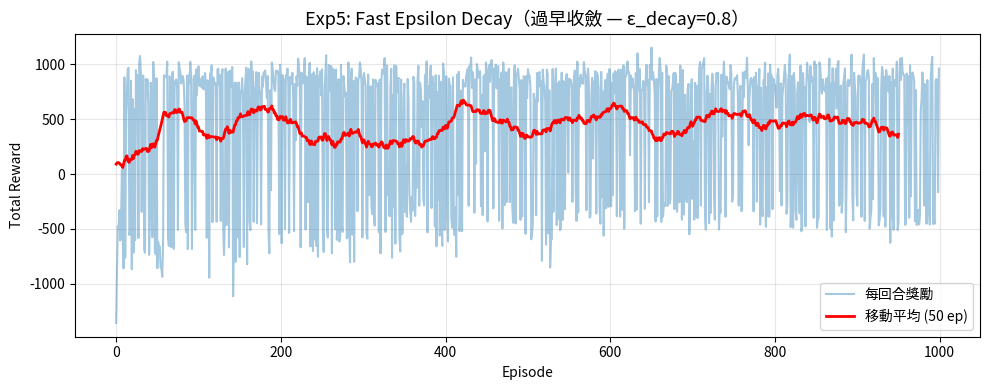

--- 測試：實驗5 (ε=0) ---
  Test  1/10 → Reward:   994.00
  Test  2/10 → Reward:   978.00
  Test  3/10 → Reward:   902.00
  Test  4/10 → Reward:   994.00
  Test  5/10 → Reward:   892.00
  Test  6/10 → Reward:   837.00
  Test  7/10 → Reward:  -480.00
  Test  8/10 → Reward:   835.00
  Test  9/10 → Reward:   858.00
  Test 10/10 → Reward:   800.00
  ★ 測試平均: 761.00



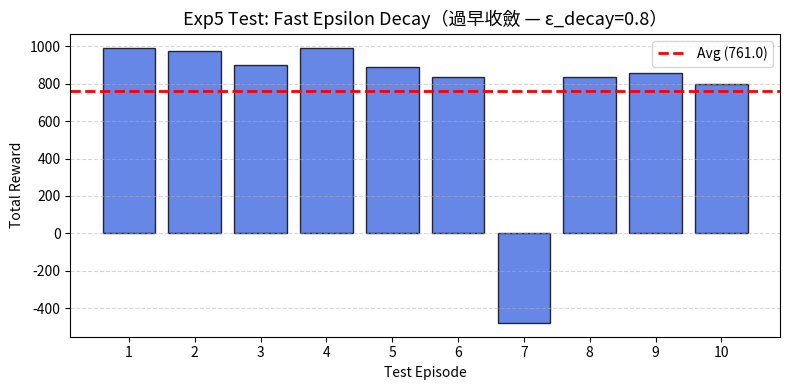

In [6]:
env = SmartGreenhouseEnv()
agent = QLearningAgent(3 * 3 * 3, 7, epsilon_decay=0.8)

# --- 訓練 ---
rewards = train(env, agent, label="實驗5 — Fast Epsilon Decay（過早收斂 — ε_decay=0.8）")
plot_train(rewards, 'Exp5: Fast Epsilon Decay（過早收斂 — ε_decay=0.8）')

# --- 測試 ---
test_r = test(env, agent, label="實驗5")
plot_test(test_r, 'Exp5 Test: Fast Epsilon Decay（過早收斂 — ε_decay=0.8）')

---
## 實驗 6：High Learning Rate（災難性遺忘 — α=1.0）

**改動**：`learning_rate=1.0`（原 0.1）。

**目的**：觀察過高學習率的災難性後果。α=1.0 意味著每次更新都完全覆寫舊的 Q 值，Agent 無法累積歷史經驗，策略隨環境隨機雜訊劇烈擺盪，永遠無法達成穩定收斂。

開始訓練：實驗6 — High Learning Rate（災難性遺忘 — α=1.0）
  Episode  200/1000 | Avg Reward:  -604.17 | ε: 0.3670
  Episode  400/1000 | Avg Reward:  -218.74 | ε: 0.1347
  Episode  600/1000 | Avg Reward:   195.14 | ε: 0.0494
  Episode  800/1000 | Avg Reward:   273.53 | ε: 0.0181
  Episode 1000/1000 | Avg Reward:   407.38 | ε: 0.0100
訓練完成！最後 200 回合平均: 407.38



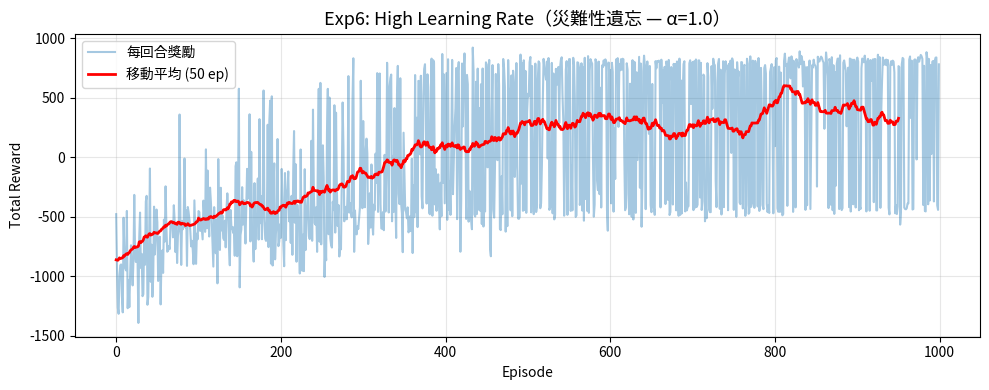

--- 測試：實驗6 (ε=0) ---
  Test  1/10 → Reward:   774.00
  Test  2/10 → Reward:   838.00
  Test  3/10 → Reward:   822.00
  Test  4/10 → Reward:   748.00
  Test  5/10 → Reward:  -430.00
  Test  6/10 → Reward:   830.00
  Test  7/10 → Reward:   769.00
  Test  8/10 → Reward:   828.00
  Test  9/10 → Reward:   847.00
  Test 10/10 → Reward:  -428.00
  ★ 測試平均: 559.80



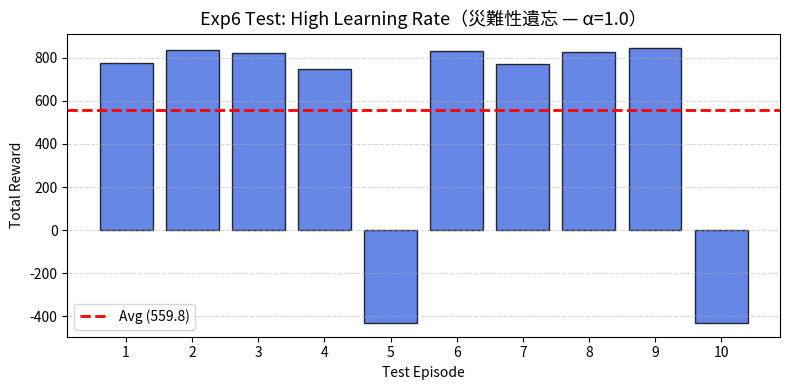

In [7]:
env = SmartGreenhouseEnv()
agent = QLearningAgent(3 * 3 * 3, 7, learning_rate=1.0)

# --- 訓練 ---
rewards = train(env, agent, label="實驗6 — High Learning Rate（災難性遺忘 — α=1.0）")
plot_train(rewards, 'Exp6: High Learning Rate（災難性遺忘 — α=1.0）')

# --- 測試 ---
test_r = test(env, agent, label="實驗6")
plot_test(test_r, 'Exp6 Test: High Learning Rate（災難性遺忘 — α=1.0）')

---
## 結論

Q-Learning 在智慧溫室中的效能，不僅取決於演算法本身，更高度依賴以下三大因素的平衡：

1. **Reward 權重設計**（實驗 2）：過重的成本懲罰會扭曲 Agent 的價值觀
2. **超參數調校**（實驗 3, 5, 6）：γ、ε_decay、α 任一極端化都會摧毀學習能力
3. **環境隨機性**（實驗 4）：Tabular Q-Learning 在高噪音環境中表現脆弱